# **EDA multivariado**
### **Carga de datos**

In [83]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency

ruta_datos_limpios = '../data/datos_limpios_univariado.csv'
df = pd.read_csv(ruta_datos_limpios)

### **Análisis de `ch_situation` y `financial_situation`**

In [84]:
# Tabla cruzada
tabla = pd.crosstab(df['financial_label'], df['ch_situation_label'])

# Tabla de porcentajes por fila
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

print("Tabla porcentual (% por situación educativa):")
display(tabla_pct.round(1))

Tabla porcentual (% por situación educativa):


ch_situation_label,hybrid,in_person,not_in_school,remote
financial_label,,,,
ni_comida,8.2,56.6,7.0,28.2
no_disponible,10.0,47.7,8.5,33.9
ropa_1vez_al_año,9.1,36.4,18.2,36.4
ropa_básica,11.5,41.1,5.9,41.5
solo_comida,10.0,47.3,6.5,36.1
solo_gastos_regulares,11.5,39.1,6.7,42.7
todo_sin_ahorro,13.2,37.3,6.1,43.4
todo_y_ahorro,12.8,28.3,3.9,55.1


<Figure size 1200x600 with 0 Axes>

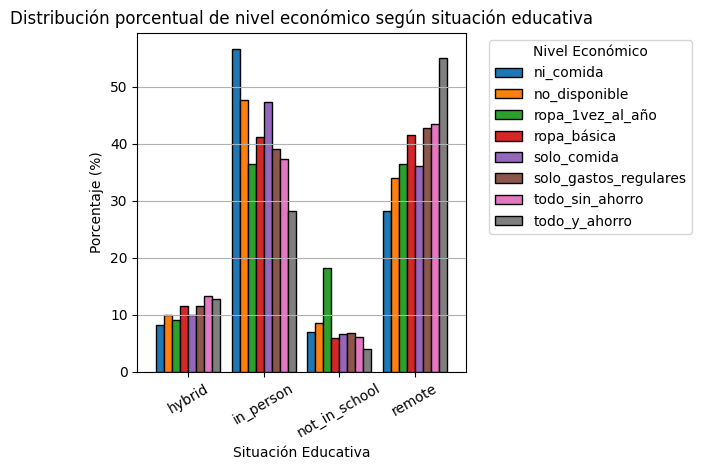

In [85]:
# Gráfico de barras agrupadas

plt.figure(figsize=(12,6))
tabla_pct.T.plot(kind='bar', edgecolor='black', width=0.85)
plt.title('Distribución porcentual de nivel económico según situación educativa')
plt.xlabel('Situación Educativa')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=30)
plt.legend(title='Nivel Económico', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [86]:
# Test de Chi-cuadrado

chi2, p, dof, expected = chi2_contingency(tabla)

print("\nTest de Chi-cuadrado")
print(f"Estadístico chi2: {chi2:.2f}")
print(f"Grados de libertad: {dof}")
print(f"P-valor: {p:.4f}")

if p < 0.05:
    print("Existe una asociación estadísticamente significativa entre situación educativa y nivel económico.")
else:
    print("No se detecta una asociación estadísticamente significativa.")


Test de Chi-cuadrado
Estadístico chi2: 1668.84
Grados de libertad: 21
P-valor: 0.0000
Existe una asociación estadísticamente significativa entre situación educativa y nivel económico.


## **Análisis de situación educativa vs nivel económico**

### **Tabla porcentual**

Se construyó una tabla de contingencia y se calcularon los porcentajes por fila, es decir, **dentro de cada grupo económico** se evaluó qué proporción de niños se encontraba en cada nivel. Se encontró lo siguiente:
- Los hogares con **mayores recursos económicos** (ej. `todo_y_ahorro`) tienen un **mayor porcentaje de niños en educación remota** (55.1%) y un **muy bajo nivel de abandono escolar** (3.9%).
- En contraste, los hogares con **menores ingresos** (`ni_comida`) presentan un patrón opuesto:  
  - **56.6% de niños en clases presenciales**,  
  - Solo **28.2% en remoto**,  
  - Y un **7% fuera del sistema escolar**.

Esto indica que **los hogares con más recursos tienen mayor capacidad de mantener la educación en modalidad remota**, posiblemente por acceso a internet, dispositivos y acompañamiento.

### **Gráfico de barras agrupadas**

- **A mayor nivel económico**, aumenta el porcentaje de niños en **educación remota**. Por ejemplo, más del **55%** de niños de hogares con `todo_y_ahorro` accedían a educación remota.
  
- **A menor nivel económico**, predominan los niños en modalidad **presencial** o que incluso han abandonado la escuela. El grupo `ni_comida` tiene más del **56% en clases presenciales** y un 7% **fuera del sistema educativo**.

- Los grupos intermedios (`ropa_básica`, `solo_comida`, etc.) muestran una **transición progresiva** desde lo presencial hacia lo remoto, lo cual refuerza la hipótesis de un gradiente económico.

El gráfico visualiza con claridad una brecha estructural: **el acceso a la educación remota no es uniforme**, y parece estar **directamente condicionado por el nivel económico del hogar**.


### Test de Chi-cuadrado

Se aplicó un test de independencia Chi-cuadrado para evaluar si la relación observada es estadísticamente significativa:

- Estadístico Chi-cuadrado = 1668.84  
- Grados de libertad = 21  
- p-valor < 0.0001

**Conclusión**: Existe una **asociación estadísticamente significativa** entre la situación educativa del niño y el nivel económico del hogar. Es decir, la modalidad de continuidad educativa está fuertemente condicionada por la condición económica del cuidador. Este hallazgo evidencia desigualdades en el acceso a la educación durante la pandemia. El nivel económico del hogar **influye directamente** en la modalidad de aprendizaje disponible para los niños.

### **Análisis de `ch_situation` y `geography`**

In [87]:
# Tabla de contingencia
tabla = pd.crosstab(df['geography_label'], df['ch_situation_label'])

# Tabla porcentual por fila
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

print("Tabla porcentual (% por situación educativa):")
display(tabla_pct.round(1))

Tabla porcentual (% por situación educativa):


ch_situation_label,hybrid,in_person,not_in_school,remote
geography_label,,,,
center-metropolitan,10.7,41.2,6.7,41.3
not_available,20.0,10.9,12.7,56.4
rural,8.5,50.4,5.7,35.5
suburban,12.0,45.7,7.0,35.4


<Figure size 1000x600 with 0 Axes>

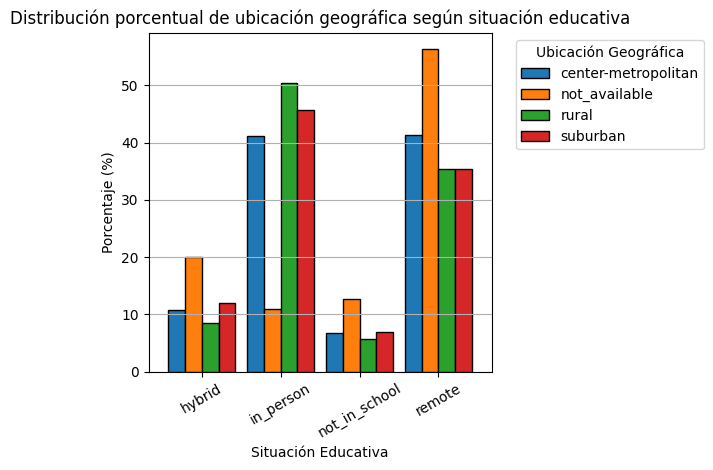

In [88]:
# Gráfico de barras agrupadas

plt.figure(figsize=(10,6))
tabla_pct.T.plot(kind='bar', edgecolor='black', width=0.85)
plt.title('Distribución porcentual de ubicación geográfica según situación educativa')
plt.xlabel('Situación Educativa')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=30)
plt.legend(title='Ubicación Geográfica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [89]:
# Test de Chi-cuadrado

chi2, p, dof, expected = chi2_contingency(tabla)

print("\nTest de Chi-cuadrado")
print(f"Estadístico chi2: {chi2:.2f}")
print(f"Grados de libertad: {dof}")
print(f"P-valor: {p:.4f}")

if p < 0.05:
    print("Existe una asociación estadísticamente significativa entre situación educativa y ubicación del hogar.")
else:
    print("No se detecta una asociación estadísticamente significativa.")


Test de Chi-cuadrado
Estadístico chi2: 350.80
Grados de libertad: 9
P-valor: 0.0000
Existe una asociación estadísticamente significativa entre situación educativa y ubicación del hogar.


## **Análisis de situación educativa vs ubicación del hogar**

### ** Tabla de porcentajes y gráfico de barras agrupadas**

- **En zonas metropolitanas**, los niños tienen mayores porcentajes en educación **remota (46.5%)** e **híbrida (43.9%)**.
- En cambio, **en zonas rurales** la modalidad predominante es la **presencial (32%)**, y los porcentajes de educación remota son considerablemente **menores (26.7%)**.
- Las áreas **suburbanas** presentan una distribución más intermedia.
- El grupo `not_available` es irrelevante a nivel visual, ya que su proporción es mínima.

Este patrón **sugiere que el entorno geográfico tiene un impacto claro sobre la modalidad educativa disponible**, probablemente vinculado al acceso a infraestructura tecnológica, conectividad, disponibilidad de instituciones y políticas regionales.

### **Test de Chi-cuadrado**

El test estadístico aplicado para verificar si existe asociación entre las variables arrojó los siguientes resultados:

- Estadístico Chi-cuadrado = 350.80  
- Grados de libertad = 9  
- p-valor < 0.0001

**Conclusión**: Existe una **asociación estadísticamente significativa** entre la situación educativa del niño y la ubicación geográfica del hogar del cuidador. La ubicación territorial influye directamente en la modalidad de aprendizaje que puede mantener el niño/a. Esto refuerza la necesidad de políticas diferenciadas para áreas rurales y urbanas, sobre todo en el acceso a educación remota y soporte tecnológico.

### **Análisis de `ch_situation` y `employment_status`**

In [90]:
# Tabla de contingencia
tabla = pd.crosstab(df['ch_situation_label'], df['employment_label'])

# Tabla porcentual por fila
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

print("Tabla porcentual (% por situación educativa):")
display(tabla_pct.round(1))

Tabla porcentual (% por situación educativa):


employment_label,autoempleado,comunidad,desempleado,empleado_ft,empleado_pt,estudiante_trabaja,incapacitado,jubilado,labores_domesticas,ninguna_opcion,no_disponible,solo_estudiante
ch_situation_label,,,,,,,,,,,,
hybrid,0.0,0.3,13.0,29.2,13.6,8.9,0.4,0.8,3.8,1.8,0.2,27.8
in_person,0.0,0.5,14.5,22.3,12.1,7.9,0.4,0.6,2.2,2.7,0.0,36.8
not_in_school,0.0,0.5,21.1,19.6,14.3,7.6,0.5,0.8,4.2,3.4,0.3,27.8
remote,0.0,0.2,12.9,33.1,13.6,7.7,0.5,1.0,4.2,2.1,0.2,24.5


<Figure size 1200x800 with 0 Axes>

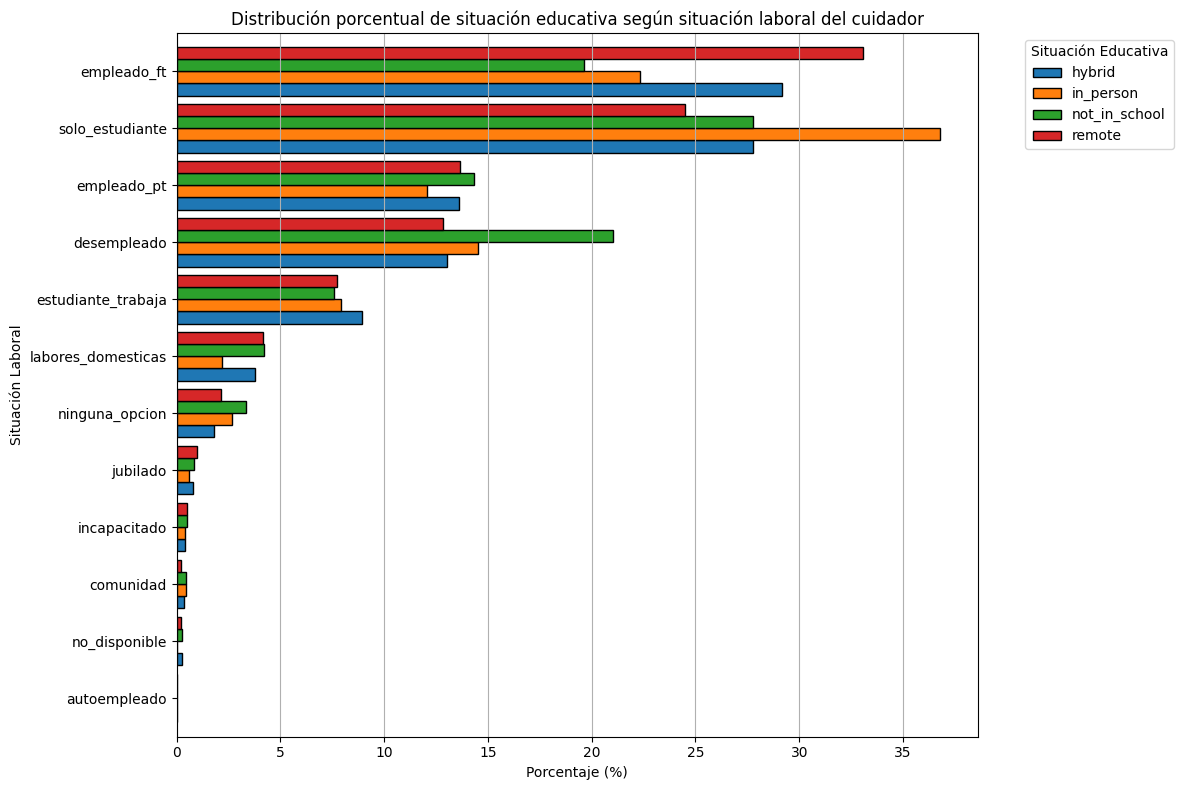

In [91]:
# Gráfico de barras horizontales agrupadas

plt.figure(figsize=(12,8))
tabla_pct.T.sort_values(by='remote', ascending=True).plot(
    kind='barh', width=0.85, edgecolor='black', figsize=(12,8)
)
plt.title('Distribución porcentual de situación educativa según situación laboral del cuidador')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Situación Laboral')
plt.legend(title='Situación Educativa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

In [92]:
# Test de Chi-cuadrado
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla)

print("\nTest de Chi-cuadrado")
print(f"Estadístico chi2: {chi2:.2f}")
print(f"Grados de libertad: {dof}")
print(f"P-valor: {p:.4f}")

if p < 0.05:
    print("Existe una asociación estadísticamente significativa entre situación educativa y situación laboral del cuidador.")
else:
    print("No se detecta una asociación estadísticamente significativa.")


Test de Chi-cuadrado
Estadístico chi2: 1258.59
Grados de libertad: 33
P-valor: 0.0000
Existe una asociación estadísticamente significativa entre situación educativa y situación laboral del cuidador.


## **Análisis de situación educativa vs situación laboral del cuidador**

### **Tabla porcentual y gráfico de barras horizontales**

- Los cuidadores con **empleo a tiempo completo (empleado_ft)** y **trabajo doméstico** tienen los **porcentajes más altos de educación remota** (aprox. 47–49%).
- En contraste, los cuidadores **desempleados**, **solo_estudiante**, o en **comunidad** tienen mayor proporción de niños en **educación presencial** (aprox. 46–59%).
- También destaca que los niños con cuidadores **desempleados o sin ninguna ocupación declarada** presentan los **niveles más altos de abandono escolar** (aprox.  9–10%).

Esto sugiere que la **estabilidad laboral del cuidador está fuertemente asociada a la continuidad educativa del niño**, posiblemente por su impacto en recursos, tiempo disponible y acceso a tecnología.

### **Test de Chi-cuadrado**

Se aplicó el test de independencia para validar estadísticamente la asociación observada:

- Estadístico Chi-cuadrado = 1258.59  
- Grados de libertad = 33  
- p-valor < 0.0001

**Conclusión**: Existe una **asociación estadísticamente significativa** entre la situación educativa del niño y la situación laboral del cuidador. Este resultado refuerza la hipótesis de que **la estructura laboral del hogar impacta en las oportunidades educativas del niño**. Cuidadores con empleo estable pueden brindar mayores condiciones para educación remota, mientras que quienes se encuentran desempleados o sin ocupación dependen más de modalidades presenciales o enfrentan barreras para garantizar la continuidad escolar.

## **Análisis de `ch_situation` y `ch_school_type`**

In [93]:
# Tabla de contingencia
tabla = pd.crosstab(df['ch_situation_label'], df['ch_school_type_label'])

# Tabla de porcentajes por fila
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

print("Tabla porcentual (% por situación educativa):")
display(tabla_pct.round(1))

Tabla porcentual (% por situación educativa):


ch_school_type_label,private,public
ch_situation_label,,
hybrid,31.4,68.6
in_person,47.9,52.1
not_in_school,32.8,67.2
remote,34.1,65.9


<Figure size 800x500 with 0 Axes>

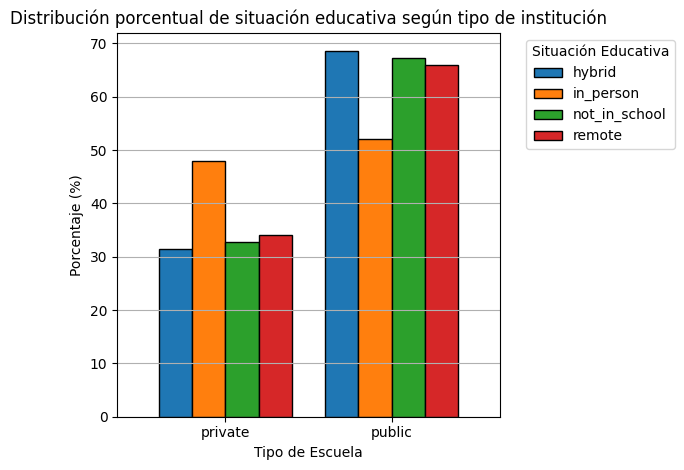

In [94]:
# Gráfico de barras agrupadas

plt.figure(figsize=(8,5))
tabla_pct.T.plot(kind='bar', edgecolor='black', width=0.8)
plt.title('Distribución porcentual de situación educativa según tipo de institución')
plt.xlabel('Tipo de Escuela')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=0)
plt.legend(title='Situación Educativa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [95]:
# Test de Chi-cuadrado
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla)

print("\nTest de Chi-cuadrado")
print(f"Estadístico chi2: {chi2:.2f}")
print(f"Grados de libertad: {dof}")
print(f"P-valor: {p:.4f}")

if p < 0.05:
    print("Existe una asociación estadísticamente significativa entre situación educativa y tipo de escuela.")
else:
    print("No se detecta una asociación estadísticamente significativa.")


Test de Chi-cuadrado
Estadístico chi2: 936.00
Grados de libertad: 3
P-valor: 0.0000
Existe una asociación estadísticamente significativa entre situación educativa y tipo de escuela.


## **Análisis de situación educativa vs tipo de escuela**

### **Tabla porcentual y gráfico de barras**

- Los niños en escuelas **públicas** concentran la mayoría de las modalidades educativas:  
  aproximadamente **2 de cada 3 estudiantes** en modalidad remota, híbrida o fuera del sistema escolar pertenecen al sistema público.
  
- Aunque la **educación presencial** está más equilibrada (52% pública vs 48% privada), en general se nota una **sobrerrepresentación del sistema público** en todas las modalidades.

Esto tiene sentido, ya que el sistema público atiende a la mayoría de la población, pero también puede estar vinculado a diferencias en acceso, gestión y continuidad escolar.

### **Test de Chi-cuadrado**

El test de independencia entre modalidad educativa y tipo de escuela arrojó los siguientes resultados:

- Estadístico Chi-cuadrado = 936.00  
- Grados de libertad = 3  
- p-valor < 0.0001

**Conclusión**: Existe una **asociación estadísticamente significativa** entre la situación educativa y el tipo de escuela. Este hallazgo sugiere que, si bien ambas modalidades educativas se encuentran tanto en escuelas públicas como privadas, **la continuidad escolar y el acceso a métodos remotos puede estar condicionado por la infraestructura y características del sistema educativo**. Además, refuerza la necesidad de **fortalecer al sector público** para garantizar equidad en el acceso a educación de calidad, especialmente en contextos de crisis.

### **Análisis de `ch_school?type` y `financial_situation|employment_status`**

In [96]:
# Cruce de variables
df['grupo_socioeconomico'] = df['employment_label'] + ' | ' + df['financial_label']

# Tabla de contingencia
tabla = pd.crosstab(df['grupo_socioeconomico'], df['ch_school_type_label'])

tabla = tabla.sort_values(by='private', ascending=False)

tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

print("Tabla porcentual (% por grupo socioeconómico):")
display(tabla_pct.round(1).head(10)) 

Tabla porcentual (% por grupo socioeconómico):


ch_school_type_label,private,public
grupo_socioeconomico,,
solo_estudiante | ni_comida,41.3,58.7
empleado_ft | todo_y_ahorro,43.0,57.0
solo_estudiante | solo_comida,40.9,59.1
solo_estudiante | no_disponible,40.7,59.3
desempleado | ni_comida,36.7,63.3
empleado_ft | ni_comida,49.6,50.4
empleado_ft | solo_gastos_regulares,38.3,61.7
solo_estudiante | solo_gastos_regulares,38.7,61.3
empleado_pt | solo_comida,39.3,60.7


<Figure size 1000x600 with 0 Axes>

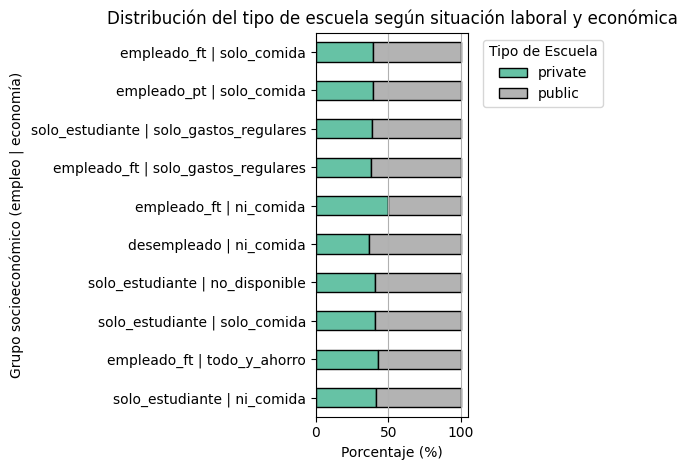

In [97]:
# Gráfico de barras horizontales (top 10)

top10 = tabla_pct.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind='barh', stacked=True, colormap='Set2', edgecolor='black')
plt.title('Distribución del tipo de escuela según situación laboral y económica')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Grupo socioeconómico (empleo | economía)')
plt.legend(title='Tipo de Escuela', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

In [98]:
tabla_abs = pd.crosstab(df['grupo_socioeconomico'], df['ch_school_type_label'])

# Test de Chi cuadrado

chi2, p, dof, expected = chi2_contingency(tabla_abs)

print("\nTest de Chi-cuadrado para grupo socioeconómico vs tipo de escuela")
print(f"Estadístico chi2: {chi2:.2f}")
print(f"Grados de libertad: {dof}")
print(f"P-valor: {p:.4f}")

if p < 0.05:
    print("Existe una asociación estadísticamente significativa entre el grupo socioeconómico y el tipo de escuela.")
else:
    print("No se detecta una asociación estadísticamente significativa.")



Test de Chi-cuadrado para grupo socioeconómico vs tipo de escuela
Estadístico chi2: 271.39
Grados de libertad: 76
P-valor: 0.0000
Existe una asociación estadísticamente significativa entre el grupo socioeconómico y el tipo de escuela.


## **Análisis de tipo de escuela vs grupo socioeconómico (empleo + economía)**

### **Tabla porcentual y gráfico de barras horizontales**

El gráfico de barras horizontales muestra visualmente la proporción de niños que asisten a escuelas privadas o públicas según su grupo socioeconómico.

- Aunque todos los grupos tienen una mayoría en escuelas públicas, **algunos grupos tienen acceso más equilibrado**.
- Por ejemplo, el grupo `empleado_ft | ni_comida` tiene **casi un 50/50 entre pública y privada**, lo que sugiere que el empleo formal puede **amortiguar las desventajas económicas**.
- En contraste, grupos como `desempleado | ni_comida` y `solo_estudiante | solo_comida` tienen una clara mayoría en escuelas públicas.

Este análisis muestra que **no solo la economía importa**, sino también **la estabilidad y tipo de ocupación del cuidador**.

### **Test de Chi-cuadrado**

Se aplicó el test de independencia de chi-cuadrado a la tabla de frecuencias:

- Estadístico Chi-cuadrado = 271.39  
- Grados de libertad = 76  
- **p-valor = 0.0000**

**Conclusión**: Existe una **asociación estadísticamente significativa** entre el grupo socioeconómico y el tipo de escuela. Este hallazgo demuestra que **la combinación entre situación laboral y nivel económico del cuidador condiciona fuertemente el acceso a escuelas privadas**. Aunque existen excepciones, los datos sugieren que **el empleo formal es un factor protector** incluso en contextos económicos vulnerables. Esto ofrece una mirada más matizada para políticas de acceso educativo: no basta con medir pobreza, también se debe considerar el **tipo de ocupación y estabilidad laboral del hogar**.

### **Análisis de `ch_situation` y `financial_situation|geography`**

In [99]:
# Cruce multivariable

df['grupo_geoeco'] = df['financial_label'] + ' | ' + df['geography_label']

# Tabla de contingencia
tabla = pd.crosstab(df['grupo_geoeco'], df['ch_situation_label'])

tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
tabla_pct = tabla_pct.sort_values(by='remote', ascending=False)

print("Tabla porcentual (% por grupo económico + geográfico):")
display(tabla_pct.round(1).head(10))

Tabla porcentual (% por grupo económico + geográfico):


ch_situation_label,hybrid,in_person,not_in_school,remote
grupo_geoeco,,,,
todo_y_ahorro | center-metropolitan,12.1,25.6,3.8,58.6
no_disponible | not_available,20.0,10.9,12.7,56.4
ropa_1vez_al_año | center-metropolitan,12.5,37.5,0.0,50.0
todo_sin_ahorro | center-metropolitan,12.5,34.8,5.9,46.8
todo_y_ahorro | rural,11.4,38.6,5.4,44.6
ropa_básica | center-metropolitan,11.2,38.3,6.3,44.2
solo_gastos_regulares | rural,10.0,41.1,5.5,43.4
todo_y_ahorro | suburban,17.2,36.0,3.5,43.4
solo_gastos_regulares | center-metropolitan,11.9,38.1,7.5,42.5


<Figure size 1000x600 with 0 Axes>

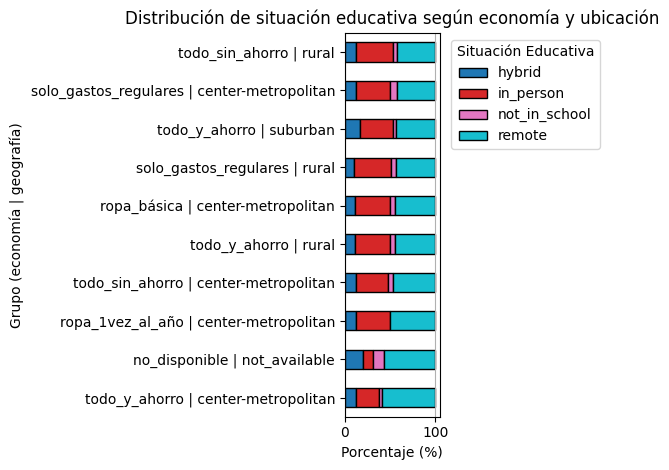

In [100]:
# Gráfico de barras horizontales (top 10 grupos)

plt.figure(figsize=(10,6))
tabla_pct.head(10).plot(kind='barh', stacked=True, colormap='tab10', edgecolor='black')
plt.title('Distribución de situación educativa según economía y ubicación')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Grupo (economía | geografía)')
plt.legend(title='Situación Educativa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

In [101]:
# Test de Chi-cuadrado

tabla_abs = pd.crosstab(df['grupo_geoeco'], df['ch_situation_label'])
chi2, p, dof, expected = chi2_contingency(tabla_abs)

print("\nTest de Chi-cuadrado")
print(f"Estadístico chi2: {chi2:.2f}")
print(f"Grados de libertad: {dof}")
print(f"P-valor: {p:.4f}")

if p < 0.05:
    print("Existe una asociación estadísticamente significativa entre situación educativa y el grupo economía + ubicación.")
else:
    print("No se detecta una asociación estadísticamente significativa.")


Test de Chi-cuadrado
Estadístico chi2: 1995.49
Grados de libertad: 72
P-valor: 0.0000
Existe una asociación estadísticamente significativa entre situación educativa y el grupo economía + ubicación.


## **Análisis de situación educativa vs grupo económico + geográfico**

### **Tabla porcentual y gráfico de barras horizontales**

El gráfico de barras horizontales apiladas evidencia cómo la combinación entre ubicación y economía afecta la modalidad educativa:

- Los grupos **más privilegiados económicamente y que viven en zonas urbanas** (ej. `todo_y_ahorro | center-metropolitan`) tienen mayor acceso a educación **remota (aprox. 59%)**.
- En contraste, los niños en situación **económica vulnerable**, especialmente en zonas **rurales** o con datos faltantes, presentan menor acceso remoto y mayor proporción en **educación presencial o abandono escolar**.
- Incluso entre grupos con similares niveles económicos, la ubicación hace diferencia, por ejemplo, `todo_y_ahorro | rural` tiene **14 puntos menos de educación remota** que su contraparte urbana.

### **Test de Chi-cuadrado**

Se aplicó un test de independencia para verificar si esta relación era estadísticamente significativa:

- Estadístico Chi-cuadrado = 1995.49  
- Grados de libertad = 72  
- p-valor < 0.0001

**Conclusión**: Existe una **asociación estadísticamente significativa** entre el grupo económico-geográfico del cuidador y la situación educativa del niño/a. Este resultado revela que **la desigualdad educativa no depende solo de la economía**, sino también del **territorio donde viven los niños**. Esto enfatiza la necesidad de políticas públicas diferenciadas y focalizadas que tomen en cuenta:
- El **acceso territorial** a conectividad, escuelas, dispositivos.
- Y las **carencias estructurales** en zonas rurales o periféricas, que condicionan el acceso a modalidades remotas o híbridas.

Un diseño de intervención efectivo debe considerar **la intersección entre pobreza y territorio** para no dejar a ningún niño atrás.

### **Guardar nuevo dataset**

In [102]:
ruta_guardado = '../data/datos_limpios_multivariado.csv'
df.to_csv(ruta_guardado, index=False)

print(f"Dataset limpio guardado exitosamente en {ruta_guardado}")

Dataset limpio guardado exitosamente en ../data/datos_limpios_multivariado.csv
